#  ML-Based Visual Quality Inspection System for Bottle Orientation


#### Iram Salim Mukri - M01092222
#### Gayathri Satheesh Lekshmi - M01087828



###  Contents 

##### 1. Engineering Problem Definition

##### 2. Dataset Collection & Feature Representation

##### 3. Neural Network Design & Optimisation

##### 4. Baseline Comparison

##### 5. Experimental Rigor

##### 6. Transfer Learning (Additional Experminent)

##### 7. Conclusion

# 1. Engineering Problem Definition

## 1.1 Engineering System Definition

This project focuses on developing a machine learning-based visual inspection system to determine whether a bottle is correctly positioned or not. The system is designed to automatically classify bottle orientation using images, replacing the need for manual inspection.

The overall system operates in two modes: dataset-based evaluation and real-time webcam testing.

In the offline setup, images of bottles are collected and processed through a trained model to classify them as either PASS or FAIL. In the live setup, a webcam continuously captures frames, and each frame is analysed in real time to produce a prediction.

The system workflow can be summarised as follows:

* A bottle is placed within a defined inspection area
* An image is captured either from a stored dataset or a live webcam feed
* The image is preprocessed and passed into a trained convolutional neural network
* The model predicts the orientation of the bottle
* A classification result is displayed:

  * **PASS** if the bottle is upright
  * **FAIL** if the bottle is tilted or lying horizontally or upside down

For the webcam system, a central region of interest is used to ensure consistent positioning, and predictions are stabilised using a short history buffer to avoid flickering outputs. This makes the system more reliable for real-time usage.



## 1.2 Inputs and Output Target

**Inputs:**

The system takes RGB images of bottles from two sources:

* A custom-built dataset containing images captured manually from different environments such as home and supermarkets
* A live webcam feed that captures frames in real time

All images are resized to a fixed resolution of **224 × 224 pixels with 3 colour channels**, ensuring consistency during training and inference.

The dataset consists of:

* **483 PASS images** (after augmentation)
* **534 FAIL images**

The images were intentionally captured under varying conditions, including both plain and slightly cluttered backgrounds, to improve the model’s ability to generalise.



**Output Target:**

The system performs binary classification with the following labels:

* **PASS (1):** Bottle is standing upright
* **FAIL (0):** Bottle is tilted or lying horizontally

For real-time webcam testing, the output is displayed directly on the video feed along with a confidence score and visual indicators.



## 1.3 Model Justification

A Convolutional Neural Network (CNN) implemented in PyTorch is used as the primary model for this task. The choice of CNN is motivated by the nature of the problem, which involves recognising spatial patterns and object orientation from images.

The model consists of multiple convolutional layers followed by fully connected layers. The convolutional layers progressively learn features such as edges, shapes, and orientation patterns, which are essential for distinguishing between upright and misaligned bottles.

ReLU activation functions are used throughout the network to introduce non-linearity, and max-pooling layers are applied to reduce spatial dimensions while retaining important features. A dropout layer is included in the fully connected section to reduce overfitting.

The model is trained using the **Adam optimiser**, which provides adaptive learning rates and faster convergence compared to basic gradient descent methods. Cross-entropy loss is used as the objective function for binary classification.

In addition to the CNN, classical machine learning models are also explored separately as baseline approaches, allowing comparison between deep learning and traditional methods.



## 1.4 Engineering Relevance and Impact

The problem addressed in this project is directly related to automated quality inspection, which is widely used in industries such as manufacturing, packaging, and logistics. In these environments, ensuring that objects are correctly oriented is critical for subsequent processes like filling, sealing, and transportation.

By automating the detection of bottle orientation, this system demonstrates how machine learning can be applied to improve efficiency and reliability in inspection tasks.

Key benefits of the proposed system include:

* Reduction in manual inspection effort and human error
* Consistent and repeatable decision-making
* Ability to process images in real time using a webcam
* Adaptability to different environments due to varied data collection

The inclusion of a real-time webcam-based inference system highlights the practical applicability of the solution. It shows how the model can be integrated into a live inspection pipeline, making it suitable for deployment in real-world scenarios where continuous monitoring is required.

Overall, this project illustrates the use of machine learning as an engineering tool for automating visual decision-making processes.



# 2. Dataset Collection & Feature Representation

### 2.1 Data Collection

The dataset used in this project was created manually by capturing images of bottles in different environments. Images were collected using a mobile camera from locations such as home and supermarkets. This approach ensured variability in lighting conditions, bottle types, and backgrounds.

The dataset consists of two classes:

* **PASS:** Bottles that are correctly positioned (upright)
* **FAIL:** Bottles that are incorrectly positioned (tilted or horizontal or upside down)

The raw dataset contains:

* PASS images: 299
* FAIL images: 537
* Total images: 998

To improve class balance and increase the diversity of the dataset, data augmentation was applied to the PASS class, resulting in a final dataset size of:

* PASS images (after augmentation): 483
* FAIL images: 533

The backgrounds were intentionally varied, including both plain and slightly cluttered scenes, to improve the model’s ability to generalise to real-world conditions.



 


### 2.2 Sample Data

#### PASS Examples (Correct Orientation)

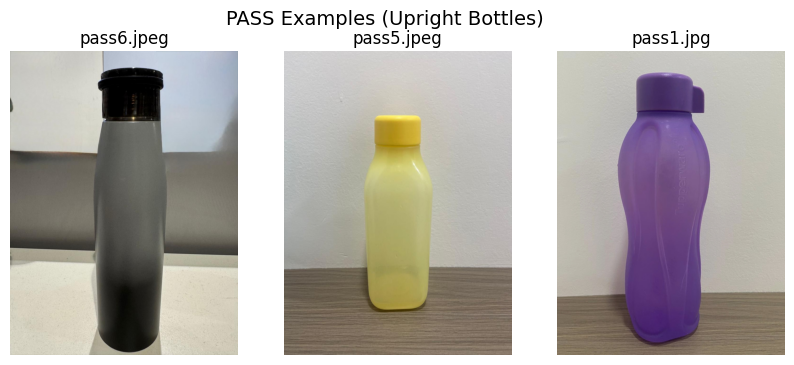

In [2]:


import os
import matplotlib.pyplot as plt
import cv2

def show_images(folder_path, title):
    images = os.listdir(folder_path)[:3]  # show first 3
    plt.figure(figsize=(10,4))
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")
    
    plt.suptitle(title, fontsize=14)
    plt.show()

show_images("../outputs/sample_images/PASS", "PASS Examples (Upright Bottles)")


#### FAIL Examples (Incorrect Orientation)


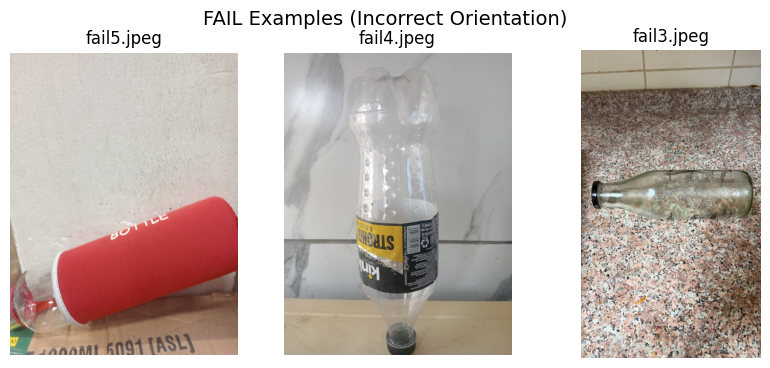

In [3]:

show_images("../outputs/sample_images/FAIL", "FAIL Examples (Incorrect Orientation)")


### 2.3 Dataset Access

The dataset is publicly accessible via the following links:

* Raw Dataset:
  [https://drive.google.com/drive/folders/1CmwW_w8F6Ga5jw4iN9z9XwTlGEC5QhQC?usp=share_link](https://drive.google.com/drive/folders/1CmwW_w8F6Ga5jw4iN9z9XwTlGEC5QhQC?usp=share_link)

* Processed Dataset:
  [https://drive.google.com/drive/folders/1WoW786aTaP5sXRNzGGBJwukieXxh8rUz?usp=share_link](https://drive.google.com/drive/folders/1WoW786aTaP5sXRNzGGBJwukieXxh8rUz?usp=share_link)

The processed dataset includes resized images and pre-split training, validation, and test sets stored as NumPy arrays.




### 2.4 Feature Extraction

Feature extraction is handled differently for the two model types used in this project: Convolutional Neural Networks (CNNs) and classical machine learning models.

For the CNN model, feature extraction is performed automatically through a sequence of convolutional layers. The input images, resized to **224 × 224 × 3**, are passed through multiple convolutional filters that learn spatial hierarchies of features. Early layers capture low-level patterns such as edges and textures, while deeper layers learn higher-level features such as bottle shape and orientation. This allows the CNN to preserve spatial relationships within the image, which is critical for orientation classification.

In contrast, classical machine learning models cannot directly process image tensors. Therefore, each image is flattened into a one-dimensional vector before being used as input. This transformation converts the 3D image structure into a long feature vector, removing spatial information between neighbouring pixels.

While flattening enables compatibility with models such as Logistic Regression and Support Vector Machines (SVM), it results in a loss of structural information, making it harder for these models to learn orientation-based features effectively.


### 2.5 Dimensionality

The dimensionality of the input data differs significantly between the CNN and traditional machine learning approaches.

From the preprocessing outputs, the input shape for the CNN model is:

* **CNN Input Shape:** (224, 224, 3)

This corresponds to a 3D tensor preserving spatial structure.

For traditional models, the same image is flattened into a one-dimensional vector:

* **Flattened Feature Dimension (N):** 150,528

This value is calculated as:

N = 224 × 224 × 3

The large dimensionality (150k+ features per image) introduces significant computational complexity for classical models. Each feature is treated independently, which increases memory usage and training time.

This high-dimensional representation makes traditional models more sensitive to noise and redundancy in the data, whereas CNNs mitigate this through local feature extraction and weight sharing.


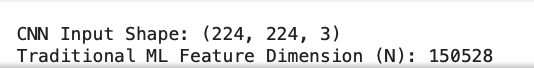

In [4]:
from IPython.display import Image, display
display(Image("../outputs/sample_images/s1.png"))

### 2.6 Impact on Model Complexity and Overfitting

The difference in feature representation has a direct impact on model complexity and the risk of overfitting.

For traditional machine learning models, the very high dimensionality (150,528 features per sample) leads to increased model complexity. Since these models operate on flattened inputs, they must learn relationships across all pixels without spatial context. This can result in numerical instability and overfitting, particularly when the dataset size is relatively small compared to the number of features.

This issue is evident in the training outputs, where runtime warnings such as overflow and invalid values were observed during matrix operations. These warnings indicate instability caused by the high-dimensional feature space and reinforce the limitations of traditional approaches for image-based tasks.

Despite this, classical models achieved reasonable performance:

However, these models rely heavily on preprocessing techniques such as scaling and dimensionality reduction (e.g., PCA) to remain stable.

In contrast, the CNN model handles complexity more efficiently. By using convolutional layers with shared weights and local receptive fields, the number of learnable parameters is significantly reduced compared to fully connected models operating on flattened inputs.

Although CNNs are also prone to overfitting due to limited data (~1000 images), this risk is mitigated through:

* Data augmentation (applied to the PASS class)
* Dropout regularisation in the fully connected layers
* Train-validation-test splitting
* Monitoring validation loss during training

Additionally, the inclusion of varied backgrounds in the dataset improves generalisation but introduces additional variability, making the learning task more challenging.

Overall, CNNs provide a more robust and scalable solution for image-based classification compared to traditional models, particularly when dealing with high-dimensional data.


# 3. Neural Network Design and Optimisation

### 3.1 CNN Architecture Design

A Convolutional Neural Network (CNN) was designed to classify bottle images into two categories: **PASS** and **FAIL**. The model processes RGB images resized to **224 × 224 × 3**.

The architecture follows a hierarchical feature extraction approach, where early layers capture low-level features (edges, textures), and deeper layers capture high-level semantic features (bottle shape, orientation).

To clearly describe the model, Table 3.1 summarises each layer, its output dimensions, and its role.

#### Table 3.1: CNN Architecture Summary

| Layer Type       | Output Shape   | Purpose                                      |
| ---------------- | -------------- | -------------------------------------------- |
| Input Layer      | (224, 224, 3)  | Raw RGB image input                          |
| Conv2D (3→16)    | (224, 224, 16) | Extract low-level features (edges, contours) |
| ReLU             | (224, 224, 16) | Introduce non-linearity                      |
| MaxPooling (2×2) | (112, 112, 16) | Downsample, reduce computation               |
| Conv2D (16→32)   | (112, 112, 32) | Learn more complex patterns                  |
| ReLU             | (112, 112, 32) | Non-linearity                                |
| MaxPooling (2×2) | (56, 56, 32)   | Further spatial reduction                    |
| Conv2D (32→64)   | (56, 56, 64)   | Capture high-level features                  |
| ReLU             | (56, 56, 64)   | Non-linearity                                |
| MaxPooling (2×2) | (28, 28, 64)   | Final feature map compression                |
| Flatten          | (50176)        | Convert 2D feature maps to 1D vector         |
| Fully Connected  | (128)          | Learn feature combinations                   |
| ReLU             | (128)          | Non-linearity                                |
| Dropout (0.5)    | (128)          | Reduce overfitting                           |
| Output Layer     | (2)            | Binary classification (PASS/FAIL)            |

The flattened feature dimension (64 × 28 × 28 = 50,176) highlights the high representational capacity of the CNN compared to traditional models

The model contains three convolutional blocks, satisfying the requirement of having at least three hidden layers. The use of **ReLU activation** ensures efficient gradient propagation, while **max pooling** reduces spatial dimensions and computational cost.

The inclusion of a **dropout layer (0.5)** is critical in preventing overfitting, especially given the relatively small dataset size (~1000 images).

Overall, this architecture provides a balance between **model capacity and generalisation**, making it suitable for image classification tasks with moderate dataset sizes.


### 3.2 Activation Function Analysis

Activation functions play a critical role in introducing non-linearity into neural networks, enabling the model to learn complex patterns in image data. In this study, four activation functions were evaluated: ReLU, Sigmoid, Tanh, and Leaky ReLU.

#### Mathematical Formulation

The activation functions used are defined as follows:

* **ReLU (Rectified Linear Unit):**
  f(x) = max(0, x)

* **Sigmoid:**
  f(x) = 1 / (1 + e^(−x))

* **Tanh:**
  f(x) = (e^x − e^(−x)) / (e^x + e^(−x))

* **Leaky ReLU:**
  f(x) = x (if x > 0), otherwise αx (α ≈ 0.01)

These functions differ in how they propagate gradients and handle negative inputs, which directly affects training stability and performance.



#### Table 3.2: Activation Function Comparison

| Activation | Output Range | Key Advantage                                | Key Limitation                | Observed Performance            |
| ---------- | ------------ | -------------------------------------------- | ----------------------------- | ------------------------------- |
| ReLU       | [0, ∞)       | Fast convergence, avoids vanishing gradients | Dead neurons possible         | High accuracy (~95–97%), stable |
| Sigmoid    | (0, 1)       | Smooth probability output                    | Severe vanishing gradient     | Poor (~50% accuracy)            |
| Tanh       | (−1, 1)      | Zero-centered output                         | Still suffers from saturation | Moderate (~88–89%)              |
| Leaky ReLU | (−∞, ∞)      | Prevents dead neurons                        | Slightly more complex         | Comparable to ReLU              |

---

#### Experimental Results and Discussion

The validation accuracy and loss curves (Figures X and Y) clearly demonstrate the impact of activation functions on learning behaviour.

ReLU achieved the best overall performance, with rapid convergence and consistently high validation accuracy. This is due to its non-saturating gradient for positive inputs, which allows efficient weight updates during backpropagation.

Leaky ReLU produced similar results, with slightly improved stability in some epochs. By allowing a small gradient for negative inputs, it avoids the "dying ReLU" problem, where neurons become inactive.

Tanh showed slower convergence compared to ReLU. Although it is zero-centered, which can aid optimisation, it still suffers from gradient saturation for large input values, limiting its effectiveness in deeper networks.

Sigmoid performed significantly worse than all other functions. Its output is bounded between 0 and 1, causing gradients to become extremely small for large positive or negative inputs. This leads to the **vanishing gradient problem**, preventing effective learning in deeper layers. This behaviour is evident in the validation accuracy remaining near random guessing (~50%).


#### Figure Analysis

The effect of activation functions on model performance is illustrated through validation loss and accuracy plots, as well as confusion matrices.

**Figure 3.2.1:** *Validation Loss Comparison across Activation Functions*

The validation loss plot shows that ReLU and Leaky ReLU exhibit a steady decrease in loss over epochs, indicating stable and effective learning. Tanh shows a slower reduction in loss, while Sigmoid remains almost constant at a high loss value (~0.69), suggesting that the model fails to learn meaningful patterns when using Sigmoid activation.

---

**Figure 3.2.2:** *Validation Accuracy Comparison across Activation Functions*

The validation accuracy plot further confirms these observations. ReLU and Leaky ReLU achieve high accuracy (~95–97%) and converge quickly. Tanh gradually improves but plateaus at a lower accuracy (~88–89%). In contrast, Sigmoid remains around 50%, equivalent to random guessing, indicating ineffective training due to vanishing gradients.

---

**Figure 3.2.3:** *Confusion Matrix (CNN with ReLU Activation)*

The confusion matrix for the ReLU-based CNN shows strong classification performance. The model correctly classifies the majority of both PASS and FAIL samples, with only a few misclassifications (e.g., 2 false positives and 6 false negatives). This demonstrates that the model generalises well across both classes.

---

**Figure 3.2.4:** *Confusion Matrix (CNN with Sigmoid Activation)*

In contrast, the Sigmoid-based model performs poorly. The confusion matrix shows that all samples are predicted as FAIL, with zero correct predictions for the PASS class. This highlights the severe limitation of Sigmoid in deep networks, where vanishing gradients prevent effective learning.

---

#### Overall Interpretation

The combination of plots and confusion matrices clearly demonstrates that activation function choice significantly impacts both learning dynamics and final model performance.

ReLU and Leaky ReLU enable efficient training and balanced classification, while Sigmoid fails to learn meaningful representations. Tanh provides moderate performance but is still inferior to ReLU-based approaches.


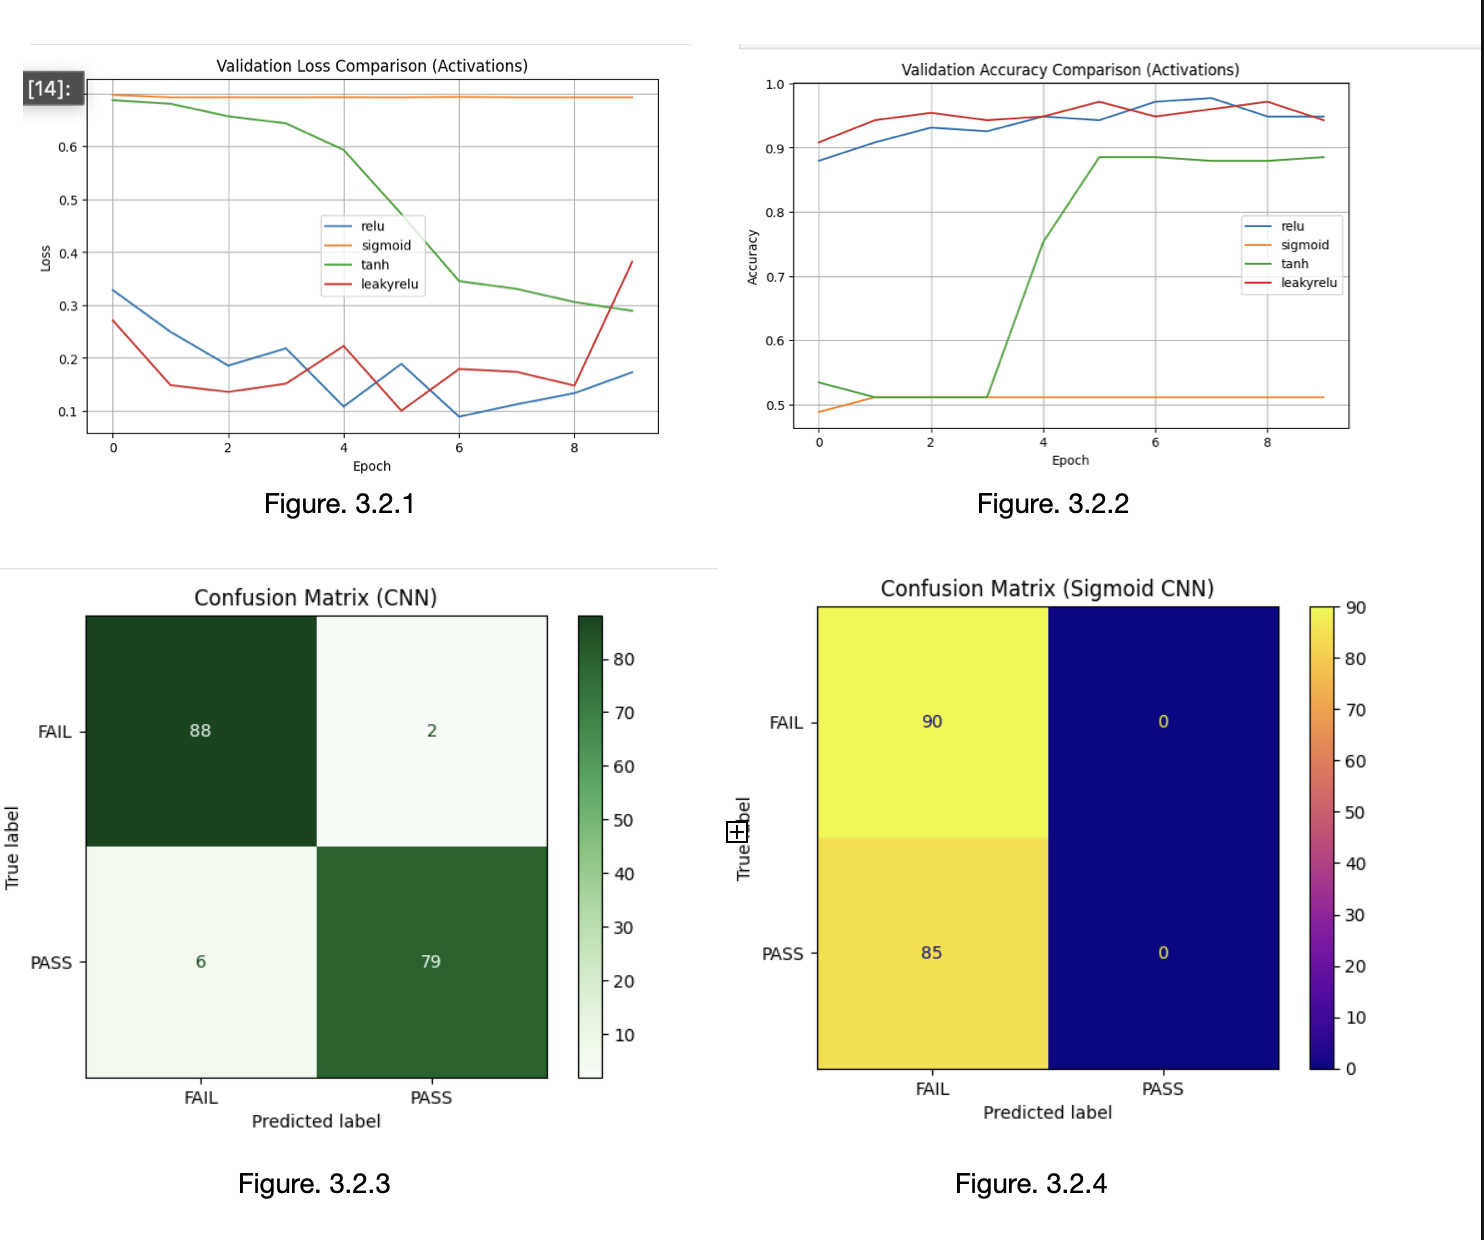

In [5]:
display(Image("../outputs/sample_images/s2.png"))

### 3.3 Optimisation Methods and Comparative Analysis

Optimisation algorithms play a crucial role in training neural networks by minimising the loss function and guiding the model toward optimal parameter values. In this study, both practical implementations and theoretical comparisons of optimisation methods were considered.

#### 3.3.1 First-Order Optimisation Methods (Implemented)

First-order methods utilise gradients of the loss function with respect to model parameters.

Two optimisers were implemented and compared:

* Stochastic Gradient Descent (SGD) with momentum
* Adam (Adaptive Moment Estimation)

The parameter update rule for standard gradient descent is:

θ = θ − η ∇L(θ)

where θ represents model parameters, η is the learning rate, and ∇L(θ) is the gradient of the loss function.



##### Adam Optimiser

Adam improves upon SGD by incorporating adaptive learning rates and momentum:

mₜ = β₁ mₜ₋₁ + (1 − β₁) gₜ
vₜ = β₂ vₜ₋₁ + (1 − β₂) gₜ²

θ = θ − η · m̂ₜ / (√v̂ₜ + ε)

This allows faster convergence and better handling of sparse gradients.



##### SGD with Momentum

SGD updates parameters using:

vₜ = μ vₜ₋₁ − η ∇L(θ)
θ = θ + vₜ

Momentum helps accelerate convergence in relevant directions but still relies on a fixed learning rate.



#### Table 3.3: Optimiser Comparison

| Optimiser | Type        | Key Advantage                            | Limitation                   | Observed Behaviour           |
| --------- | ----------- | ---------------------------------------- | ---------------------------- | ---------------------------- |
| Adam      | First-order | Adaptive learning rate, fast convergence | Slightly higher memory usage | Rapid loss reduction, stable |
| SGD       | First-order | Simple, stable updates                   | Slow convergence             | Gradual loss decrease        |




**Figure 3.3.1:** *Validation Loss Comparison (Adam vs SGD)*

The validation loss curves show that Adam converges significantly faster than SGD. Within the first few epochs, Adam reduces validation loss sharply, reaching values below 0.1. In contrast, SGD shows a slower, more gradual decline in loss and remains at a higher final loss value (~0.24).

This demonstrates that Adam is more efficient for this task, particularly due to its adaptive learning rate and momentum-based updates.





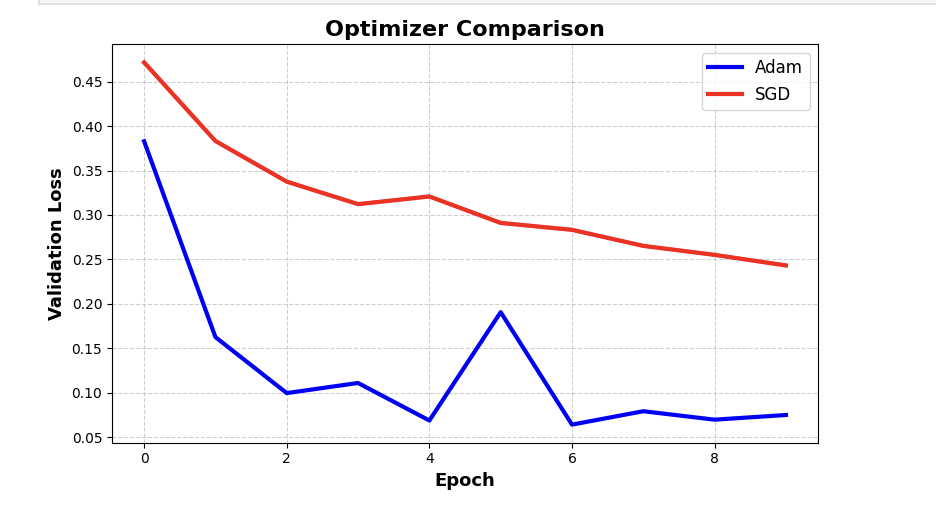

In [6]:
display(Image("../outputs/sample_images/s3.png"))

#### 3.3.2 Zero-Order Optimisation (Conceptual Analysis)

Zero-order optimisation methods do not use gradient information and instead rely solely on function evaluations. Examples include:

* Random Search
* Genetic Algorithms
* Evolutionary Strategies

These methods estimate optimal parameters by exploring the search space without gradient guidance.

However, for deep learning models such as CNNs, zero-order methods are impractical due to:

* Extremely high parameter dimensionality (tens of thousands of parameters)
* High computational cost of evaluating each candidate solution
* Slow convergence compared to gradient-based methods

Thus, zero-order methods were not implemented, as they are not suitable for large-scale neural networks.


#### 3.3.3 Second-Order Optimisation (Conceptual Analysis)

Second-order methods use curvature information (second derivatives) to improve optimisation efficiency.

The update rule is:

θ = θ − H⁻¹ ∇L(θ)

where H is the Hessian matrix.

Examples include:

* Newton’s Method
* Quasi-Newton methods (e.g., L-BFGS)

While these methods can provide faster convergence in theory, they are rarely used in deep learning due to:

* Extremely high computational cost of computing the Hessian
* Memory limitations for large models
* Difficulty in inversion of large matrices

Given the CNN architecture used in this study, second-order methods were not feasible.



#### Table 3.4: Summary of Optimisation Methods

| Method Type  | Uses Gradient        | Computational Cost | Suitability for CNN |
| ------------ | -------------------- | ------------------ | ------------------- |
| Zero-Order   | No                   | Very High          | Not suitable        |
| First-Order  | Yes                  | Moderate           | Highly suitable     |
| Second-Order | Yes (2nd derivative) | Very High          | Not practical       |


#### Key Insight

The experimental and theoretical analysis confirms that **first-order methods, particularly Adam**, provide the best balance between computational efficiency and convergence speed for CNN-based image classification tasks.

Zero-order and second-order methods, while theoretically valuable, are not practical for high-dimensional deep learning problems.


### 3.4 Convergence Analysis

The convergence behaviour of the CNN model was analysed using training and validation loss curves over multiple epochs.

**Figure 3.4.1:** *Convergence Plot (Training vs Validation Loss)*

The convergence plot illustrates a rapid decrease in training loss during the initial epochs, dropping from approximately 0.51 to below 0.1. This indicates that the model quickly learns meaningful feature representations from the input data.

The validation loss also decreases initially, demonstrating that the model generalises well during early training stages. However, after a few epochs, minor fluctuations in validation loss are observed. For instance, a temporary increase around epoch 3 suggests sensitivity to variations in the validation set.

Despite these fluctuations, the validation loss stabilises within a narrow range (approximately 0.13–0.19), indicating that the model does not suffer from severe overfitting. The relatively small gap between training and validation loss further supports good generalisation performance.

The continued decrease in training loss, combined with stabilised validation loss, suggests that the model is approaching convergence toward a local minimum.



#### Key Observations

* **Fast initial convergence:** The model rapidly reduces loss in early epochs, indicating effective learning.
* **Stable validation behaviour:** No significant divergence between training and validation curves.
* **Mild fluctuations:** Likely due to limited dataset size and inherent variability.
* **Controlled overfitting:** The gap between curves remains small, supported by dropout regularisation.



#### Interpretation

The convergence pattern demonstrates that the optimisation process is stable and well-behaved. The use of the Adam optimiser contributes to smooth and efficient convergence, while the CNN architecture effectively captures relevant features without excessive overfitting.

Overall, the model achieves a good balance between **learning capacity and generalisation**, making it suitable for the classification task.


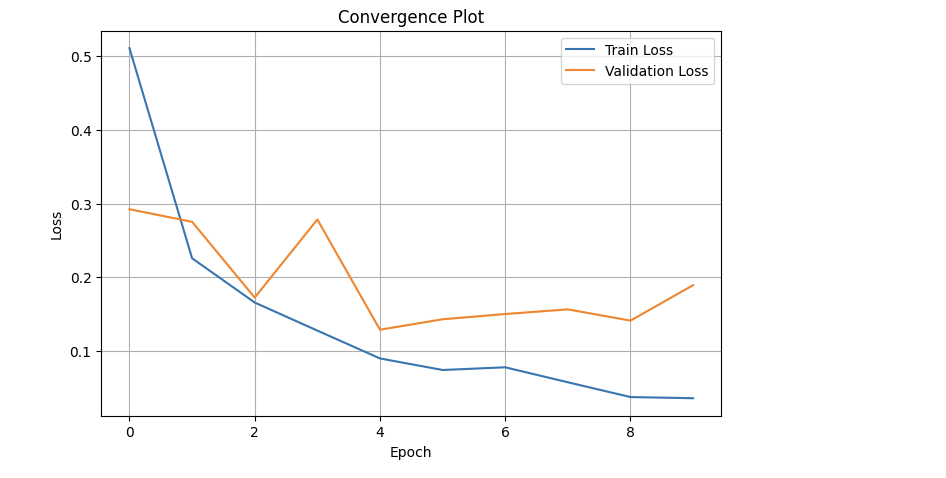

In [7]:
display(Image("../outputs/sample_images/s4.png"))

# 4. Baseline Comparison

To evaluate the effectiveness of the proposed CNN model, several classical machine learning models were implemented as baselines, including Logistic Regression, Linear SVM, and RBF SVM (with PCA). These models were trained on flattened image features and compared based on performance and generalisation ability.



### 4.1 Model Performance Comparison

The validation and test accuracies for each baseline model are summarised in Table 4.1.

**Table 4.1:**

The results indicate that **Logistic Regression** achieves the lowest performance due to its linear nature, which limits its ability to capture complex patterns in image data.

The **Linear SVM** improves upon this by maximising the margin between classes, leading to better classification boundaries and higher accuracy.

The best-performing classical model is **RBF SVM with PCA**, which achieves a test accuracy of **90.0%**. The RBF kernel enables modelling of non-linear relationships, while PCA reduces feature dimensionality and removes noise, improving learning efficiency.



### 4.2 Generalisation Analysis

Generalisation refers to how well a model performs on unseen data. This is evaluated by comparing validation and test accuracies.

**Figure 4.1.1:** *Validation vs Test Accuracy (Generalisation)*

The results show that all models demonstrate relatively consistent performance between validation and test sets, indicating stable generalisation.

* Logistic Regression shows a noticeable gap between validation (0.8054) and test (0.8467), suggesting slight underfitting.
* Linear SVM maintains closer values, indicating improved generalisation.
* RBF SVM exhibits the most consistent behaviour, with minimal difference between validation (0.9128) and test (0.9000), suggesting strong robustness.

Overall, the small gaps between validation and test accuracy across models indicate that **overfitting is limited**.



### 4.3 Comparison with CNN Model

The CNN model achieves a test accuracy of approximately **91.4%**, outperforming all classical models.

This performance difference can be attributed to:

* **Automatic feature extraction:** CNNs learn hierarchical features (edges, textures, shapes), whereas classical models rely on raw pixel inputs.
* **Spatial awareness:** CNNs preserve spatial relationships, unlike flattened representations used in traditional models.
* **Higher representational power:** Deep architectures can model complex patterns more effectively.

While the RBF SVM performs competitively, it still depends on manual feature preprocessing (flattening and PCA), whereas the CNN learns features directly from the data.



### 4.4 Insights

* Classical models can achieve strong performance, especially with non-linear kernels (RBF SVM).
* Dimensionality reduction (PCA) significantly improves traditional model performance.
* CNNs outperform classical models due to their ability to learn spatial and hierarchical features.
* The relatively small performance gap suggests that the dataset is moderately complex and can be partially captured by traditional methods.



### 4.5 Conclusion

The baseline comparison demonstrates that while classical machine learning models provide a strong benchmark, deep learning approaches such as CNNs offer superior performance and better feature learning capabilities. This highlights the importance of model selection based on data complexity and representation requirements.


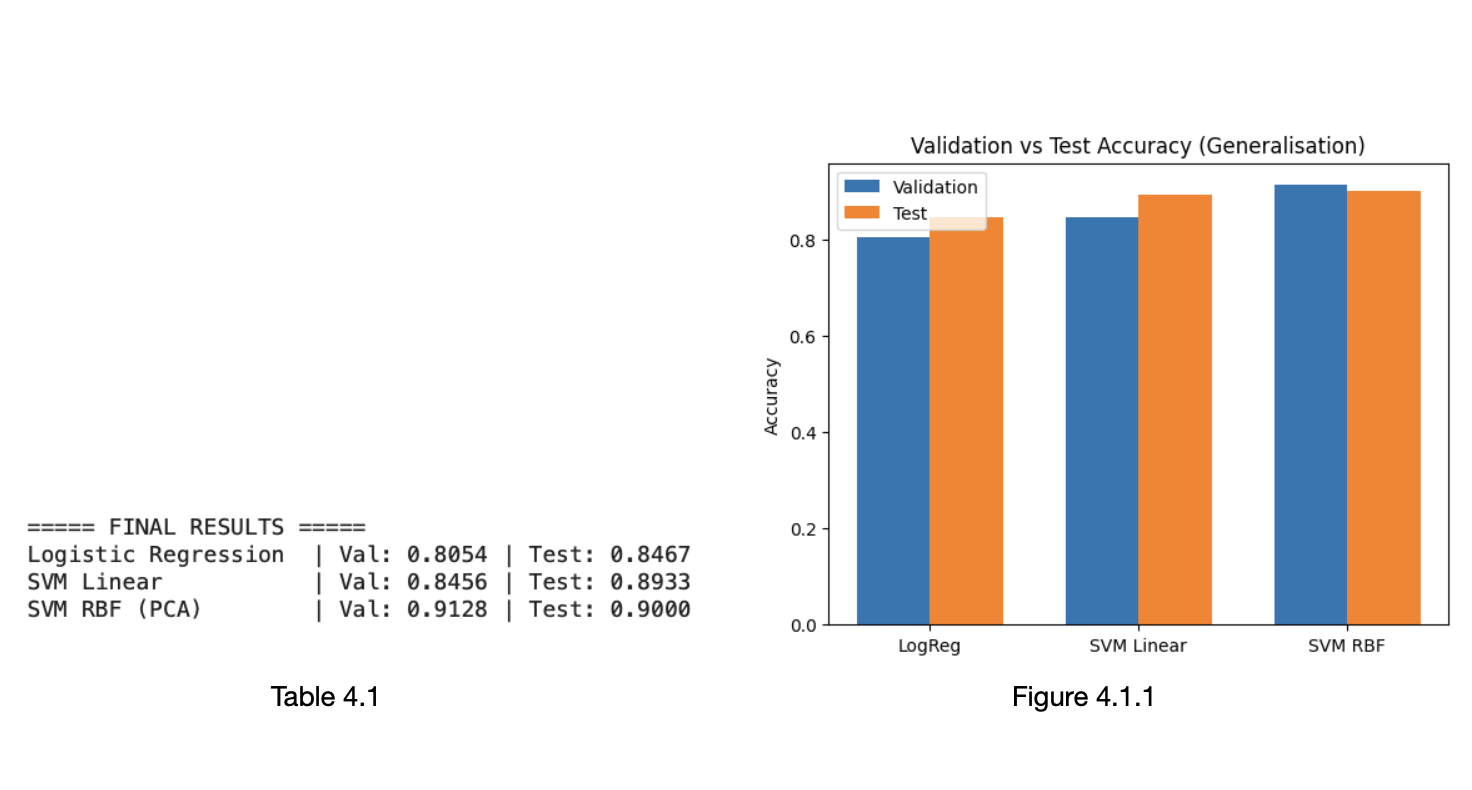

In [8]:
display(Image("../outputs/sample_images/s5.png"))

# 5. Experimental Rigor

To ensure the reliability and validity of the experimental results, a structured evaluation methodology was employed. This includes a clear dataset split, cross-validation, and overfitting analysis.


### 5.1 Train–Validation–Test Split

The dataset was divided into three mutually exclusive subsets to ensure unbiased evaluation:

* **Training set (70%)**: Used to learn model parameters
* **Validation set (15%)**: Used for hyperparameter tuning and monitoring model performance
* **Test set (15%)**: Used only for final evaluation

**Dataset Distribution:**

| Split      | Samples | Shape              |
| ---------- | ------- | ------------------ |
| Training   | 812     | (812, 3, 224, 224) |
| Validation | 174     | (174, 3, 224, 224) |
| Test       | 175     | (175, 3, 224, 224) |

This separation ensures that the model does not learn from validation or test data, thereby preventing **data leakage** and enabling a fair assessment of generalisation performance.


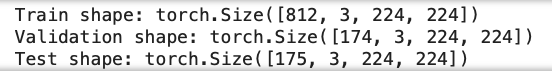

In [9]:
display(Image("../outputs/sample_images/s6.png"))

### 5.2 Cross-Validation

While a single train-validation split provides one estimate of model performance, it may be sensitive to how the data is partitioned. To address this, **k-fold cross-validation (k = 5)** was applied.

#### Methodology:

* The combined training and validation data were divided into **5 equal folds**
* In each iteration:

  * 4 folds were used for training
  * 1 fold was used for validation
* This process was repeated 5 times, ensuring every sample is used for validation exactly once

Mathematically, the cross-validation estimate of accuracy is:

[
\bar{A} = \frac{1}{k} \sum_{i=1}^{k} A_i
]

where ( A_i ) is the accuracy of the model on the ( i^{th} ) fold.

#### Results:

| Metric             | Value  |
| ------------------ | ------ |
| Mean Accuracy      | 0.9503 |
| Standard Deviation | 0.0067 |

#### Interpretation:

* The **high mean accuracy (95.03%)** indicates strong overall performance across different data subsets
* The **low standard deviation (0.0067)** suggests that the model’s performance is stable and not highly sensitive to data variation
* This implies **low variance**, meaning the model generalises consistently across different training conditions

In contrast, a high standard deviation would indicate instability and potential overfitting to specific subsets.

Thus, cross-validation confirms that the model is **robust and not dependent on a particular data split**.



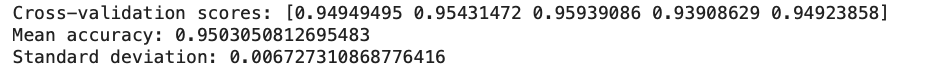

In [10]:
display(Image("../outputs/sample_images/s7.png"))

### 5.3 Overfitting Analysis

Overfitting occurs when a model learns the training data too well, including noise and irrelevant patterns, resulting in poor performance on unseen data.

To analyse this, training and validation accuracy were tracked over multiple epochs.

**Figure 5.1: Training vs Validation Accuracy**

#### Observations:

* Training accuracy increases steadily and reaches approximately **98–99%**
* Validation accuracy follows a similar upward trend and stabilises around **94–96%**
* The gap between training and validation accuracy remains relatively small (≈2–4%)


* A **small gap** between training and validation accuracy indicates good generalisation
* If overfitting were present, training accuracy would continue increasing while validation accuracy would decrease
* The absence of divergence between the two curves suggests that the model is not memorising the data

Some minor fluctuations in validation accuracy are observed, which can be attributed to:

* Stochastic gradient updates
* Limited dataset size
* Variability in mini-batch sampling

#### Regularisation Effect:

The use of **Dropout (p = 0.5)** in the fully connected layer plays a significant role in controlling overfitting by randomly deactivating neurons during training. This prevents co-adaptation of features and encourages the model to learn more general representations.




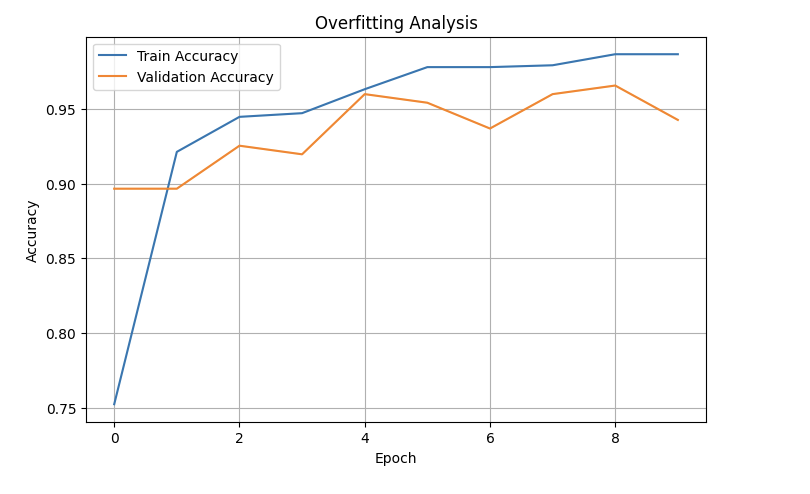

In [11]:
display(Image("../outputs/sample_images/s8.png"))

### 5.4 Conclusion
The combination of these evaluation techniques provides a comprehensive assessment of model reliability:

* The **data split strategy** ensures unbiased evaluation
* **Cross-validation** reduces dependency on a single partition and confirms stability
* **Overfitting analysis** validates that the model generalises well without memorisation

Together, these methods demonstrate that the model is both **accurate and statistically reliable**.
The experimental design ensures a high level of rigor in model evaluation. The consistent performance across cross-validation folds, combined with minimal overfitting, indicates that the proposed CNN model is robust and capable of generalising effectively to unseen data.


# 6. Transfer Learning (Additional Experiment)

To further improve performance, transfer learning was applied using a pre-trained **ResNet18** model.


### 6.1 Methodology

* Pre-trained ResNet18 was used
* Final layer modified for binary classification (PASS / FAIL)
* Earlier layers retained to leverage learned features
* Model fine-tuned on the dataset



### 6.2 Performance

| Model             | Test Accuracy |
| ----------------- | ------------- |
| CNN (Custom)      | 0.9144        |
| Transfer Learning | **0.9429**    |

The transfer learning model achieved higher accuracy, demonstrating the advantage of using pre-trained feature representations.


### 6.3 Confusion Matrix Analysis

**Figure 6.1.1: Confusion Matrix (ResNet18)**

* Correctly classified FAIL: 88
* Correctly classified PASS: 77
* False Positives: 2
* False Negatives: 8

The model shows strong overall performance with very few misclassifications, indicating good class separation.

Transfer learning improves performance by leveraging pre-trained features, leading to better accuracy and generalisation compared to the custom CNN.


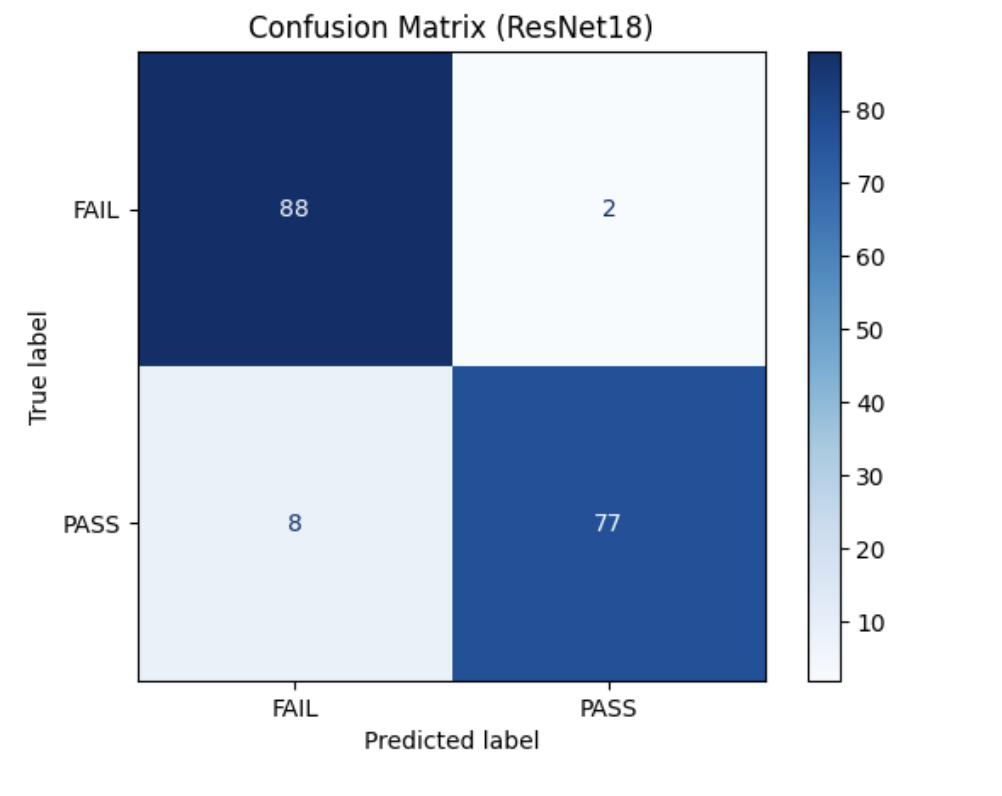

In [12]:
display(Image("../outputs/sample_images/s9.png"))

# 7. Conclusion and Future Work


### 7.1 Summary of Findings

This study investigated image-based classification using both traditional machine learning models and a Convolutional Neural Network

**Key Results:**

| Model               | Test Accuracy |
| ------------------- | ------------- |
| Logistic Regression | 0.8467        |
| SVM (Linear)        | 0.8933        |
| SVM (RBF + PCA)     | 0.9000        |
| CNN (Proposed)      | **0.9144**    |
| Transfer Learning   | **0.9429**    |

The CNN model achieved the highest accuracy among the baseline models, demonstrating its effectiveness in learning spatial and hierarchical features directly from images. Additionally, the transfer learning approach further improved performance, highlighting the benefit of leveraging pre-trained deep representations.


### 7.2 Insights

* CNN outperforms traditional models due to **automatic feature extraction**
* Flattened features in classical models lead to **loss of spatial information**
* PCA improves traditional models by reducing noise and dimensionality
* Cross-validation confirms **model stability and reliability**
* Minimal gap between training and validation accuracy indicates **good generalisation**
* Transfer learning further enhances performance by utilising **pre-trained feature representations**


### 7.3 Strengths of the Approach

| Aspect           | Strength                                           |
| ---------------- | -------------------------------------------------- |
| Dataset Handling | Proper split prevents data leakage                 |
| Feature Learning | CNN learns features automatically                  |
| Model Evaluation | Includes cross-validation and overfitting analysis |
| Performance      | High accuracy with stable results                  |



### 7.4 Limitations

* Dataset size is relatively small, which may limit generalisation to unseen real-world data
* Class imbalance required augmentation, which may introduce bias
* Traditional models rely on flattened features, losing spatial relationships



### 7.5 Future Work

To further improve performance and robustness, the following extensions are recommended:

* Experiment with **deeper architectures** and batch normalization
* Explore **advanced optimisation methods** (e.g., AdamW, learning rate schedulers)
* Increase dataset size for improved generalisation


### 7.6 Final Conclusion

Overall, the proposed CNN model demonstrates strong performance and generalisation capability for the classification task. While classical models provide a solid baseline, deep learning approaches offer superior feature representation and accuracy. The additional improvement achieved through transfer learning further reinforces the effectiveness of leveraging pre-trained models for enhanced performance.
